In [48]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [49]:
dataset_path = r"C:\Users\wtpir\Documents\images pro\archive\human detection dataset"

images = []
labels = []

for label in ["0","1"]:

    folder = os.path.join(dataset_path,label)

    for file in tqdm(os.listdir(folder)):

        img_path = os.path.join(folder,file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img,(128,128))
        img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

        images.append(img)
        labels.append(int(label))

images = np.array(images)
labels = np.array(labels)

print("Dataset size:",images.shape)

100%|██████████| 559/559 [00:03<00:00, 146.30it/s]

Dataset size: (921, 128, 128)


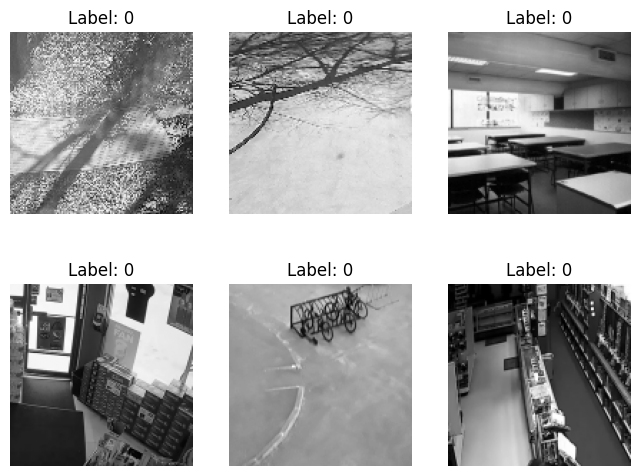

In [50]:
plt.figure(figsize=(8,6))

for i in range(6):

    plt.subplot(2,3,i+1)
    plt.imshow(images[i],cmap='gray')
    plt.title("Label: "+str(labels[i]))
    plt.axis("off")

plt.show()

In [51]:
smoothed_images = []

for img in images:
    blur = cv2.GaussianBlur(img,(5,5),0)
    smoothed_images.append(blur)

smoothed_images = np.array(smoothed_images)

In [52]:
from skimage.feature import hog

features = []

for img in smoothed_images:

    hog_feature = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys'
    )

    features.append(hog_feature)

features = np.array(features)

print("Feature shape:", features.shape)

Feature shape: (921, 8100)


In [53]:
X_train,X_test,y_train,y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42
)

print("Train:",X_train.shape)
print("Test:",X_test.shape)

Train: (736, 8100)
Test: (185, 8100)


In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=10, gamma='scale')
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.77      0.57      0.66        80
           1       0.73      0.87      0.79       105

    accuracy                           0.74       185
   macro avg       0.75      0.72      0.72       185
weighted avg       0.74      0.74      0.73       185



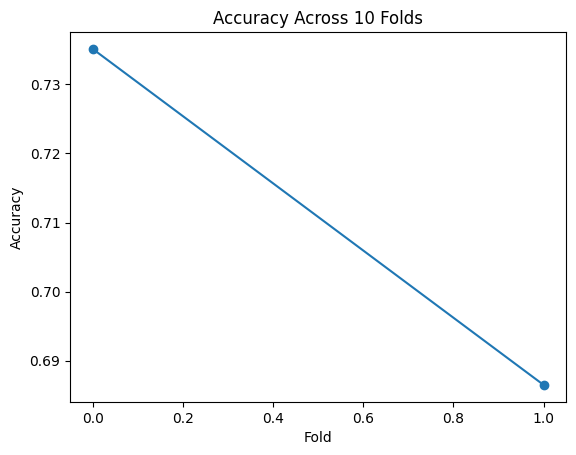

In [55]:
plt.plot(scores, marker='o')

plt.title("Accuracy Across 10 Folds")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.show()

In [56]:
rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train,y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test,rf_pred)

print("Random Forest Accuracy:",rf_accuracy)

Random Forest Accuracy: 0.6594594594594595


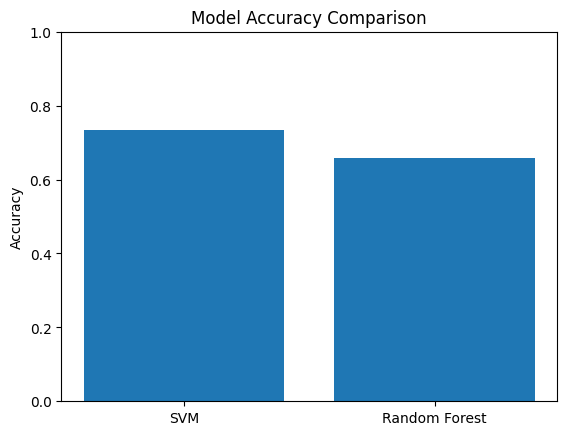

In [57]:
models = ["SVM","Random Forest"]
scores = [svm_accuracy,rf_accuracy]

plt.bar(models,scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

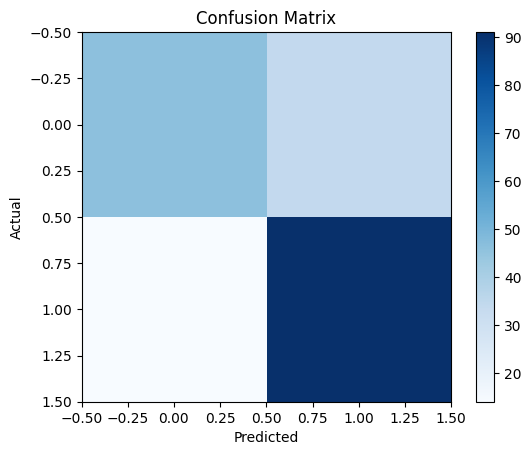

In [58]:
cm = confusion_matrix(y_test,svm_pred)

plt.imshow(cm,cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()

In [59]:
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           0       0.77      0.57      0.66        80
           1       0.73      0.87      0.79       105

    accuracy                           0.74       185
   macro avg       0.75      0.72      0.72       185
weighted avg       0.74      0.74      0.73       185



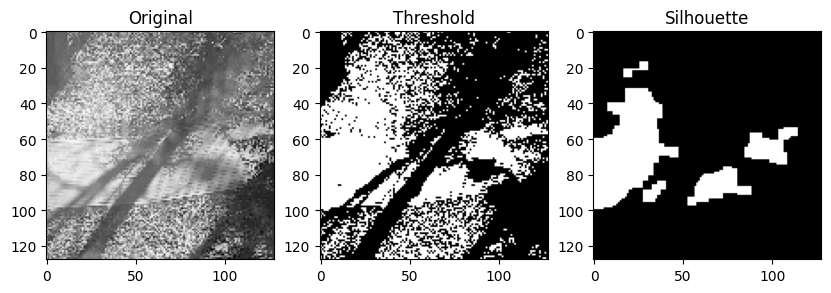

In [60]:
test_img = images[0]

_,thresh = cv2.threshold(test_img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

kernel = np.ones((5,5),np.uint8)

opening = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel)

closing = cv2.morphologyEx(opening,cv2.MORPH_CLOSE,kernel)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(test_img,cmap="gray")
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(thresh,cmap="gray")
plt.title("Threshold")

plt.subplot(1,3,3)
plt.imshow(closing,cmap="gray")
plt.title("Silhouette")

plt.show()

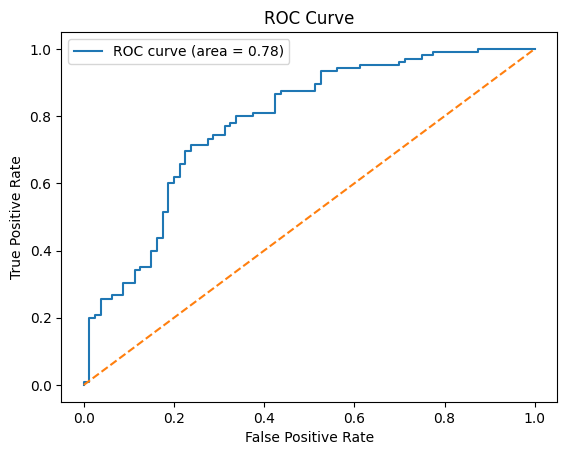

In [61]:
from sklearn.metrics import roc_curve, auc

y_scores = svm_model.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_scores)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

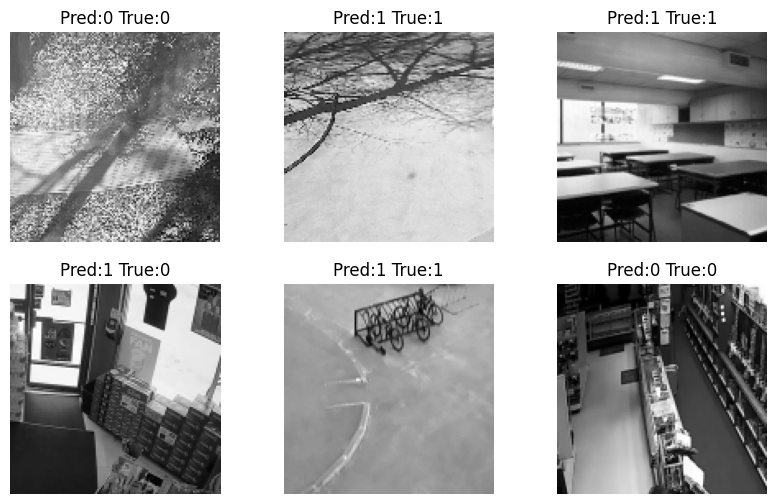

In [62]:
plt.figure(figsize=(10,6))

for i in range(6):

    img = X_test[i]

    pred = svm_model.predict([img])[0]
    true = y_test[i]

    image_display = images[i]

    plt.subplot(2,3,i+1)
    plt.imshow(image_display,cmap="gray")
    plt.title(f"Pred:{pred} True:{true}")
    plt.axis("off")

plt.show()